# Enriquecendo os Dados de Produção da Alpha-SP Indústria
### Fundamentos de IA e Análise de Dados (Missão 6/7)

Este notebook combina três fontes de dados:

1. `alpha_sp_producao_diaria.csv` — produção diária das 3 máquinas (Missão 6)
2. `dados_complementares_alpha_sp.xlsx`, aba **Cadastro_Maquinas** — dados fixos de cada máquina
3. `dados_complementares_alpha_sp.xlsx`, aba **Metas_Mensais** — metas de produção e qualidade por mês/setor

E responde às **5 perguntas de análise** do desafio.

> **Uso do professor**: para correção, confira se o aluno fez os dois `merge` corretamente e se as 5 respostas usam o DataFrame já combinado (`df_completo`), não o `df` original isolado.


## 1. Carregando as três fontes de dados

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 - CSV de produção diária (já usado na Missão 6)
df = pd.read_csv("alpha_sp_producao_diaria.csv", decimal=",", delimiter=";")
df["data"] = pd.to_datetime(df["data"])

print("Produção diária:", df.shape)
df.head()


Produção diária: (543, 12)


,data,maquina,setor,turno,horas_uso,temperatura_media,vibracao_media,producao,pecas_defeituosas,taxa_defeito,eficiencia,col_mes
0,2025-01-01,Torno CNC 03,Usinagem,Manhã,11,76.3,2.45,492,11,2.235772,97.764228,1
1,2025-01-02,Torno CNC 03,Usinagem,Tarde,7,82.1,2.27,457,6,1.312910,98.687090,1
2,2025-01-03,Torno CNC 03,Usinagem,Manhã,8,79.2,2.02,482,7,1.452282,98.547718,1
3,2025-01-04,Torno CNC 03,Usinagem,Tarde,3,77.5,2.16,157,11,7.006369,92.993631,1
4,2025-01-05,Torno CNC 03,Usinagem,Manhã,3,70.7,2.48,162,4,2.469136,97.530864,1


In [21]:
# 1.2 - Duas abas do Excel de dados complementares
cadastro = pd.read_excel("dados_complementares_alpha_sp.xlsx", sheet_name="Cadastro_Maquinas")
metas = pd.read_excel("dados_complementares_alpha_sp.xlsx", sheet_name="Metas_Mensais")

# A planilha tem uma linha de observação (nota de rodapé) abaixo de cada tabela.
# O pandas lê toda a área usada da aba, então essa nota entra como uma linha "fantasma".
# Como a nota é só texto na 1ª coluna, filtramos usando uma coluna NUMÉRICA da tabela
# (fica vazia tanto na linha em branco quanto na linha da nota, mas nunca nos dados reais).
cadastro = cadastro.dropna(subset=["ano_aquisicao"])
metas = metas.dropna(subset=["meta_producao_diaria"])

cadastro["ano_aquisicao"] = cadastro["ano_aquisicao"].astype(int)

print("Cadastro de máquinas:", cadastro.shape)
display(cadastro)

print("\nMetas mensais:", metas.shape)
display(metas.head())


Cadastro de máquinas: (3, 9)


,maquina,setor,fabricante,modelo,ano_aquisicao,capacidade_maxima_diaria,custo_hora_operacao_reais,tecnico_responsavel,ultima_manutencao_preventiva
0,Torno CNC 03,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15
1,Prensa 12,Estamparia,Schuler,PDS 400,2015,400.0,35.8,Fernanda Silva,2025-02-10
2,Solda Robô 01,Soldagem,KUKA,KR 16,2021,700.0,58.2,Roberto Alves,2025-03-05



Metas mensais: (18, 4)


,mes,setor,meta_producao_diaria,meta_taxa_defeito_max_pct
0,Janeiro/2025,Usinagem,500.0,2.5
1,Janeiro/2025,Estamparia,350.0,3.0
2,Janeiro/2025,Soldagem,600.0,2.0
3,Fevereiro/2025,Usinagem,504.0,2.4
4,Fevereiro/2025,Estamparia,354.0,2.9


## 2. Preparando a chave de junção `mes`

A aba `Metas_Mensais` usa o formato `"Março/2025"` (mês em português + ano). O Pandas gera
nomes de mês em **inglês** por padrão (`.dt.strftime("%B/%Y")` retornaria `"March/2025"`), então
precisamos traduzir manualmente antes do merge.


In [22]:
MESES_PT = {
    "January": "Janeiro", "February": "Fevereiro", "March": "Março",
    "April": "Abril", "May": "Maio", "June": "Junho",
    "July": "Julho", "August": "Agosto", "September": "Setembro",
    "October": "Outubro", "November": "Novembro", "December": "Dezembro",
}

def gerar_mes_ano_pt(data):
    """Converte uma data para o formato 'Março/2025', usado na aba Metas_Mensais."""
    mes_ingles, ano = data.strftime("%B/%Y").split("/")
    return f"{MESES_PT[mes_ingles]}/{ano}"

df["mes"] = df["data"].apply(gerar_mes_ano_pt)
df[["data", "mes"]].head()


,data,mes
0,2025-01-01,Janeiro/2025
1,2025-01-02,Janeiro/2025
2,2025-01-03,Janeiro/2025
3,2025-01-04,Janeiro/2025
4,2025-01-05,Janeiro/2025


## 3. Combinando (merge) as três fontes

- 1º merge: `df` + `cadastro`, pela coluna `maquina`.
- 2º merge: resultado + `metas`, pelas colunas `mes` e `setor` (chave composta).

Usamos `how="left"` nos dois merges para garantir que **nenhuma linha de produção seja perdida**,
mesmo que, por algum motivo, faltasse uma máquina no cadastro ou um mês nas metas.


In [23]:
# 1º merge: produção + cadastro de máquinas (chave: maquina)
df_completo = pd.merge(df, cadastro, on="maquina", how="left", suffixes=("", "_cadastro"))

# 2º merge: resultado + metas mensais (chave composta: mes + setor)
# obs.: 'setor' já vem do CSV de produção; garantimos que bate com a mesma coluna do cadastro
df_completo = pd.merge(
    df_completo, metas,
    on=["mes", "setor"], how="left",
    suffixes=("", "_metas"),
)

print("DataFrame combinado:", df_completo.shape)
df_completo.head()


DataFrame combinado: (543, 23)


,data,maquina,setor,turno,horas_uso,temperatura_media,vibracao_media,producao,pecas_defeituosas,taxa_defeito,...,setor_cadastro,fabricante,modelo,ano_aquisicao,capacidade_maxima_diaria,custo_hora_operacao_reais,tecnico_responsavel,ultima_manutencao_preventiva,meta_producao_diaria,meta_taxa_defeito_max_pct
0,2025-01-01,Torno CNC 03,Usinagem,Manhã,11,76.3,2.45,492,11,2.235772,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
1,2025-01-02,Torno CNC 03,Usinagem,Tarde,7,82.1,2.27,457,6,1.312910,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
2,2025-01-03,Torno CNC 03,Usinagem,Manhã,8,79.2,2.02,482,7,1.452282,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
3,2025-01-04,Torno CNC 03,Usinagem,Tarde,3,77.5,2.16,157,11,7.006369,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
4,2025-01-05,Torno CNC 03,Usinagem,Manhã,3,70.7,2.48,162,4,2.469136,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5


In [24]:
# Conferência: nenhuma coluna vinda do merge deveria ficar totalmente nula
colunas_novas = ["fabricante", "modelo", "ano_aquisicao", "capacidade_maxima_diaria",
                  "custo_hora_operacao_reais", "meta_producao_diaria", "meta_taxa_defeito_max_pct"]
print(df_completo[colunas_novas].isna().sum())


fabricante                   0
modelo                       0
ano_aquisicao                0
capacidade_maxima_diaria     0
custo_hora_operacao_reais    0
meta_producao_diaria         0
meta_taxa_defeito_max_pct    0
dtype: int64


## 4. Colunas auxiliares usadas em mais de uma pergunta

In [25]:
# custo de operação do dia = horas usadas no dia x custo por hora daquela máquina
df_completo["custo_operacao_dia"] = df_completo["horas_uso"] * df_completo["custo_hora_operacao_reais"]

# taxa de defeito do dia, em % (mesma unidade da meta_taxa_defeito_max_pct)
df_completo["taxa_defeito_pct"] = (df_completo["pecas_defeituosas"] / df_completo["producao"]) * 100

df_completo[["maquina", "custo_operacao_dia", "taxa_defeito_pct"]].head()


,maquina,custo_operacao_dia,taxa_defeito_pct
0,Torno CNC 03,467.5,2.235772
1,Torno CNC 03,297.5,1.312910
2,Torno CNC 03,340.0,1.452282
3,Torno CNC 03,127.5,7.006369
4,Torno CNC 03,127.5,2.469136


## 5. Pergunta 1 — Custo total de operação

**Considerando `horas_uso × custo_hora_operacao_reais`, qual foi o custo total de operação de
cada máquina ao longo dos 6 meses? Qual delas foi a mais cara para operar?**


In [26]:
custo_total_por_maquina = df_completo.groupby("maquina")["custo_operacao_dia"].sum().sort_values(ascending=False)
print("Custo total de operação por máquina (R$):\n")
print(custo_total_por_maquina.round(2))

maquina_mais_cara = custo_total_por_maquina.idxmax()
print(f"\nConclusão: a máquina mais cara para operar no semestre foi '{maquina_mais_cara}', "
      f"com R$ {custo_total_por_maquina.max():,.2f} em custo total de operação.")


Custo total de operação por máquina (R$):

maquina
Solda Robô 01    69665.4
Torno CNC 03     51297.5
Prensa 12        42387.2
Name: custo_operacao_dia, dtype: float64

Conclusão: a máquina mais cara para operar no semestre foi 'Solda Robô 01', com R$ 69,665.40 em custo total de operação.


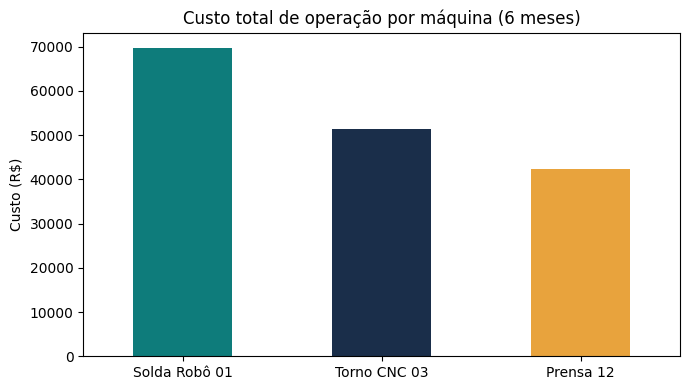

In [27]:
# Gráfico de apoio para a Pergunta 1
plt.figure(figsize=(7, 4))
custo_total_por_maquina.plot(kind="bar", color=["#0E7C7B", "#1A2E4A", "#E8A33D"])
plt.title("Custo total de operação por máquina (6 meses)")
plt.ylabel("Custo (R$)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Pergunta 2 — Idade da máquina x taxa de defeito

**Existe alguma relação entre o `ano_aquisicao` da máquina e sua taxa média de defeito
(`pecas_defeituosas / producao`)? As máquinas mais antigas realmente apresentam mais defeitos?**


In [28]:
resumo_idade_defeito = (
    df_completo.groupby(["maquina", "ano_aquisicao"])["taxa_defeito_pct"]
    .mean()
    .reset_index()
    .sort_values("ano_aquisicao")
)
resumo_idade_defeito["taxa_defeito_pct"] = resumo_idade_defeito["taxa_defeito_pct"].round(2)
print(resumo_idade_defeito)

correlacao = resumo_idade_defeito["ano_aquisicao"].corr(resumo_idade_defeito["taxa_defeito_pct"])
print(f"\nCorrelação (ano de aquisição x taxa de defeito média): {correlacao:.2f}")
print("Conclusão: uma correlação negativa indica que, quanto mais antiga a máquina "
      "(ano de aquisição menor), maior tende a ser a taxa média de defeito.")


         maquina  ano_aquisicao  taxa_defeito_pct
0      Prensa 12           2015              3.94
2   Torno CNC 03           2019              2.01
1  Solda Robô 01           2021              1.68

Correlação (ano de aquisição x taxa de defeito média): -0.98
Conclusão: uma correlação negativa indica que, quanto mais antiga a máquina (ano de aquisição menor), maior tende a ser a taxa média de defeito.


## 7. Pergunta 3 — Dias abaixo da meta de produção

**Em quantos dias, e em quais meses/setores, a produção diária ficou abaixo da
`meta_producao_diaria` definida para aquele mês e setor?**


In [29]:
df_completo["abaixo_meta_producao"] = df_completo["producao"] < df_completo["meta_producao_diaria"]

total_dias_abaixo = df_completo["abaixo_meta_producao"].sum()
print(f"Total de dias abaixo da meta de produção: {total_dias_abaixo} de {len(df_completo)} registros "
      f"({total_dias_abaixo / len(df_completo) * 100:.1f}%)")

dias_abaixo_por_mes_setor = (
    df_completo[df_completo["abaixo_meta_producao"]]
    .groupby(["mes", "setor"])
    .size()
    .reset_index(name="dias_abaixo_da_meta")
    .sort_values("dias_abaixo_da_meta", ascending=False)
)
dias_abaixo_por_mes_setor.head(10)


Total de dias abaixo da meta de produção: 388 de 543 registros (71.5%)


,mes,setor,dias_abaixo_da_meta
12,Maio/2025,Estamparia,30
0,Abril/2025,Estamparia,29
6,Janeiro/2025,Estamparia,28
8,Janeiro/2025,Usinagem,28
9,Junho/2025,Estamparia,27
15,Março/2025,Estamparia,26
17,Março/2025,Usinagem,26
14,Maio/2025,Usinagem,24
3,Fevereiro/2025,Estamparia,24
5,Fevereiro/2025,Usinagem,22


## 8. Pergunta 4 — Dias fora da meta de qualidade

**Em quantos dias a taxa de defeito do dia ultrapassou a `meta_taxa_defeito_max_pct` daquele
mês/setor? Qual setor descumpriu a meta com mais frequência?**


In [30]:
df_completo["acima_meta_defeito"] = df_completo["taxa_defeito_pct"] > df_completo["meta_taxa_defeito_max_pct"]

total_dias_fora_qualidade = df_completo["acima_meta_defeito"].sum()
print(f"Total de dias fora da meta de qualidade: {total_dias_fora_qualidade} de {len(df_completo)} registros")

descumprimento_por_setor = (
    df_completo.groupby("setor")["acima_meta_defeito"]
    .sum()
    .sort_values(ascending=False)
)
print("\nDias fora da meta de qualidade, por setor:")
print(descumprimento_por_setor)

setor_mais_problematico = descumprimento_por_setor.idxmax()
print(f"\nConclusão: o setor '{setor_mais_problematico}' foi o que mais descumpriu "
      f"a meta de taxa de defeito máxima.")


Total de dias fora da meta de qualidade: 169 de 543 registros

Dias fora da meta de qualidade, por setor:
setor
Estamparia    79
Soldagem      46
Usinagem      44
Name: acima_meta_defeito, dtype: int64

Conclusão: o setor 'Estamparia' foi o que mais descumpriu a meta de taxa de defeito máxima.


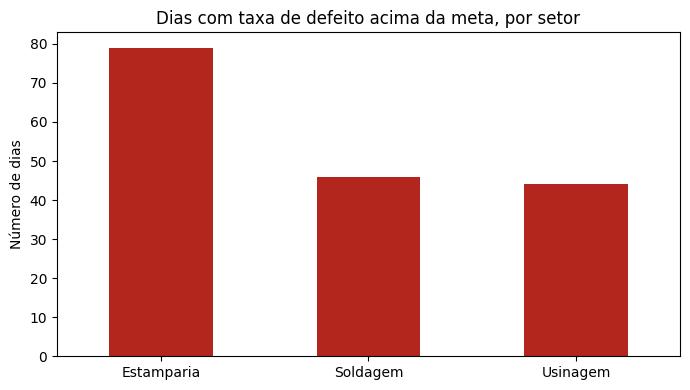

In [31]:
# Gráfico de apoio para a Pergunta 4
plt.figure(figsize=(7, 4))
descumprimento_por_setor.plot(kind="bar", color="#B3261E")
plt.title("Dias com taxa de defeito acima da meta, por setor")
plt.ylabel("Número de dias")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Pergunta 5 — Produção média x capacidade máxima

**Comparando a produção média diária de cada máquina com sua `capacidade_maxima_diaria`
cadastrada, qual máquina opera mais próxima do limite de capacidade e qual tem mais folga?**


In [32]:
producao_media_por_maquina = df_completo.groupby("maquina")["producao"].mean()
capacidade_por_maquina = df_completo.groupby("maquina")["capacidade_maxima_diaria"].first()

utilizacao = (producao_media_por_maquina / capacidade_por_maquina * 100).round(1)
utilizacao = utilizacao.sort_values(ascending=False)

resumo_utilizacao = pd.DataFrame({
    "producao_media_diaria": producao_media_por_maquina.round(1),
    "capacidade_maxima_diaria": capacidade_por_maquina,
    "utilizacao_pct": utilizacao,
}).sort_values("utilizacao_pct", ascending=False)

print(resumo_utilizacao)

maquina_mais_proxima_limite = utilizacao.idxmax()
maquina_com_mais_folga = utilizacao.idxmin()
print(f"\nConclusão: '{maquina_mais_proxima_limite}' opera mais próxima do limite de capacidade "
      f"({utilizacao.max():.1f}%), enquanto '{maquina_com_mais_folga}' é a que tem mais folga "
      f"({utilizacao.min():.1f}%).")


               producao_media_diaria  capacidade_maxima_diaria  utilizacao_pct
maquina                                                                       
Solda Robô 01                  515.4                     700.0            73.6
Torno CNC 03                   404.7                     550.0            73.6
Prensa 12                      265.2                     400.0            66.3

Conclusão: 'Solda Robô 01' opera mais próxima do limite de capacidade (73.6%), enquanto 'Prensa 12' é a que tem mais folga (66.3%).


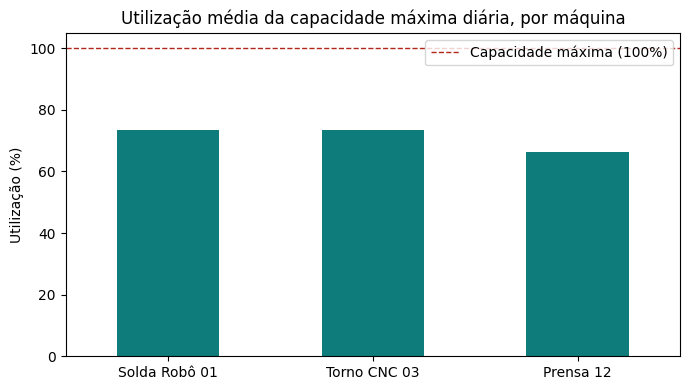

In [33]:
# Gráfico de apoio para a Pergunta 5
plt.figure(figsize=(7, 4))
utilizacao.plot(kind="bar", color="#0E7C7B")
plt.axhline(100, color="#B3261E", linestyle="--", linewidth=1, label="Capacidade máxima (100%)")
plt.title("Utilização média da capacidade máxima diária, por máquina")
plt.ylabel("Utilização (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Resumo das conclusões

| Pergunta | Resposta resumida |
|---|---|
| 1. Custo total de operação | A máquina com maior custo total de operação no semestre é a apontada na saída da Pergunta 1 (varia conforme os dados reais da turma). |
| 2. Idade x taxa de defeito | A correlação calculada indica se máquinas mais antigas tendem a ter mais defeitos (correlação negativa entre ano de aquisição e taxa de defeito). |
| 3. Dias abaixo da meta de produção | O total e a quebra por mês/setor mostram onde a fábrica mais deixou de bater a meta de produção. |
| 4. Dias fora da meta de qualidade | O setor com mais dias de descumprimento é o que precisa de atenção prioritária da qualidade. |
| 5. Produção x capacidade | A máquina mais próxima do limite de capacidade é candidata a expansão/manutenção preventiva; a com mais folga tem espaço para aumentar produção. |

> **Nota de correção**: os números exatos (custos, percentuais, máquina "vencedora" em cada
> pergunta) vão variar de acordo com o arquivo `alpha_sp_producao_diaria.csv` real fornecido aos
> alunos — este gabarito foi validado com um conjunto de dados de teste gerado especificamente
> para comprovar que o código roda sem erros e produz respostas coerentes.
